# Part 1 ‐ Exploratory data analysis

We import the `logins.json` file and create a timeseries visualization of logins at the given geographical location.

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
from dateutil.relativedelta import relativedelta
import seaborn as sns

In [2]:
import statsmodels.api as sm
from statsmodels.graphics.api import abline_plot
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn import linear_model, preprocessing
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.pipeline import make_pipeline
from sklearn.metrics import root_mean_squared_error, r2_score
 
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.filterwarnings(action="ignore", module="scipy", message="^internal gelsd")

In [3]:
df = pd.read_json('logins.json')

## Initial EDA

In [4]:
df.head()

,login_time
0,1970-01-01 20:13:18
1,1970-01-01 20:16:10
2,1970-01-01 20:16:37
3,1970-01-01 20:16:36
4,1970-01-01 20:26:21


In [5]:
df.describe()

,login_time
count,93142
mean,1970-02-26 19:09:39.779648278
min,1970-01-01 20:12:16
25%,1970-02-04 10:37:19.750000
50%,1970-03-01 06:33:05.500000
75%,1970-03-22 04:01:10.750000
max,1970-04-13 18:57:38


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93142 entries, 0 to 93141
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   login_time  93142 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 727.8 KB


<Axes: title={'center': 'Logins'}>

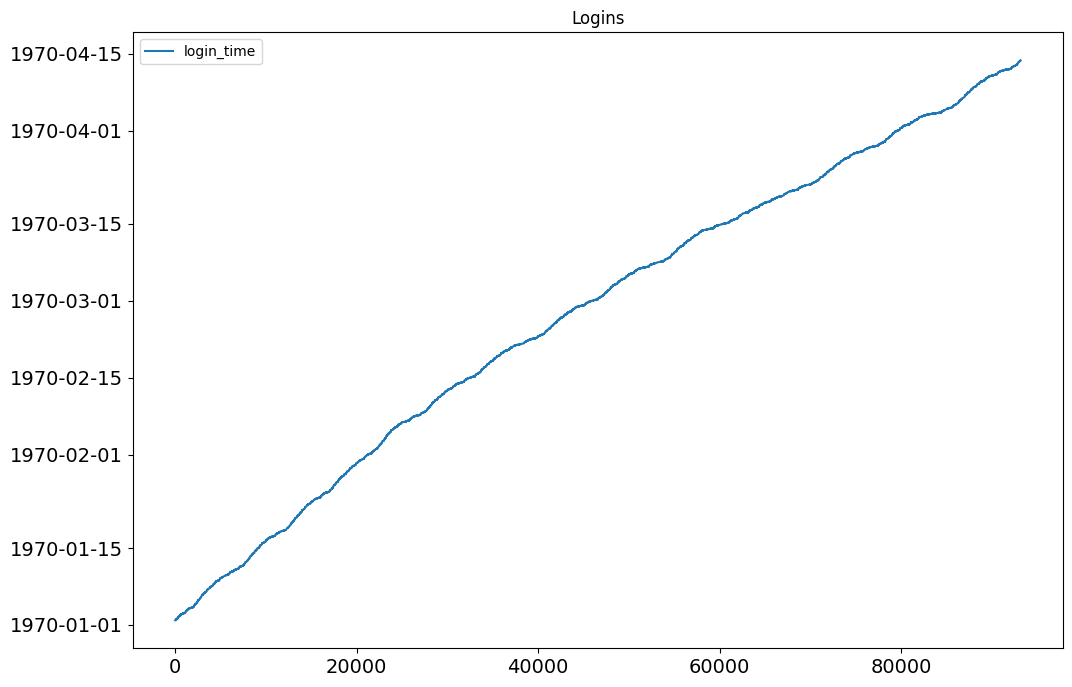

In [7]:
df.plot(figsize=(12,8), title='Logins', fontsize=14)

The data appears to be solid. There were no null values and there were a significant number of entries.

The data increases linearly in terms of time. There are a few light patterns visible in the line.

## Breaking into 15-Minute Intervals

Let's break the data into varying types of fifteen-minute increments.

In [8]:
df['15min_inc'] = df['login_time'].dt.floor('15min')

In [9]:
df['month'] = df['login_time'].dt.month

In [10]:
df['day_name'] = df['login_time'].dt.day_name()

In [11]:
df['15min_as_str'] = df['15min_inc'].dt.time.apply(lambda x: x.strftime('%H:%M'))

In [12]:
df.head(2)

,login_time,15min_inc,month,day_name,15min_as_str
0,1970-01-01 20:13:18,1970-01-01 20:00:00,1,Thursday,20:00
1,1970-01-01 20:16:10,1970-01-01 20:15:00,1,Thursday,20:15


### Basic 15-Minute Intervals

In [13]:
counts_15min = df['15min_as_str'].value_counts().sort_index()

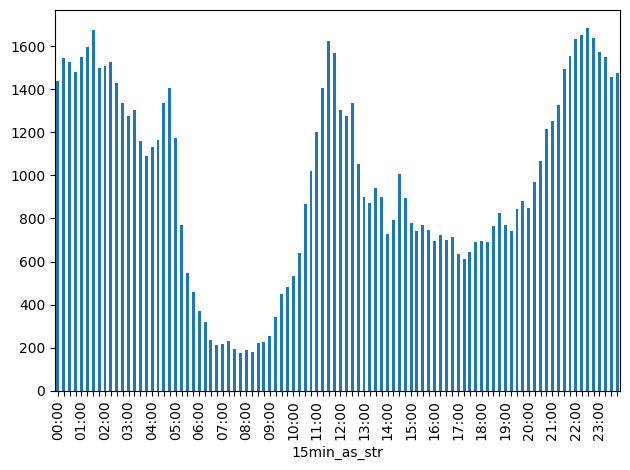

In [14]:
ax = counts_15min.plot.bar()
n = 4
for index, label in enumerate(ax.get_xticklabels()):
    if index % n != 0:
        label.set_visible(False)

plt.tight_layout()
plt.show()

In general, the logins are high in the early hours of the morning, around noon, and in the late night. The logins are lowest in the normal morning hours.

### Day of the Week and 15-Min Incremenets

In [15]:
def day_as_dig(day):
   if day == 'Monday':
       return '00'
   elif day == 'Tuesday':
       return '01'
   elif day == 'Wednesday':
       return '02'
   elif day == 'Thursday':
       return '03'
   elif day == 'Friday':
       return '04'
   elif day == 'Saturday':
       return '05'
   elif day == 'Sunday':
       return '06'

df['day_as_dig'] = df['day_name'].apply(day_as_dig)
                                                

In [16]:
df['day_15min'] = df['day_as_dig'] + ' ' + df['15min_as_str']

In [17]:
df.head(2)

,login_time,15min_inc,month,day_name,15min_as_str,day_as_dig,day_15min
0,1970-01-01 20:13:18,1970-01-01 20:00:00,1,Thursday,20:00,03,03 20:00
1,1970-01-01 20:16:10,1970-01-01 20:15:00,1,Thursday,20:15,03,03 20:15


In [18]:
counts_day_15min = df['day_15min'].value_counts()

In [19]:
counts_day_15min

day_15min
06 04:45    584
06 04:30    549
06 04:15    495
05 04:45    485
06 04:00    479
           ... 
02 06:45     11
02 06:30     10
01 06:45     10
03 06:30      7
00 06:30      7
Name: count, Length: 672, dtype: int64

In [20]:
counts_day_15min = counts_day_15min.sort_index()

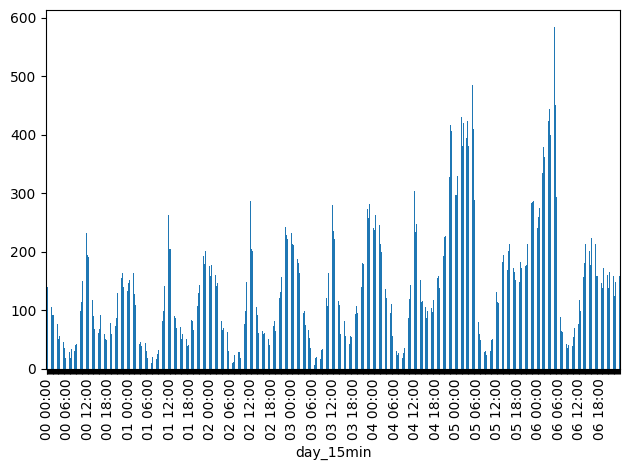

In [21]:
ax = counts_day_15min.plot.bar()
n = 24
for index, label in enumerate(ax.get_xticklabels()):
    if index % n != 0:
        label.set_visible(False)

plt.tight_layout()
plt.show()

We can see that for each day of the week, there is a peak around noon and midnight, with the later wave tapering off towards six o'clock in the morning. This would suggest that people are logging on during their lunch break and in the middle of the night. 

On Friday and Saturday, this pattern continues, but with much higher numbers and the logins increasing throughout the night up to six o'clock.

# Part 2: Experiment and Metrics Design

**1 What would you choose as the key measure of success of this experiment in
encouraging driver partners to serve both cities, and why would you choose this metric?**

I would need data that showed the driver, their point of origin, their time of crossing, and the direction of their cross.

This data would allow us to determine the drivers, their frequency and direction of crossing, and whether or not the frequency is increasing. 

**2 Describe a practical experiment you would design to compare the effectiveness of the proposed change in relation to the key measure of success.**

Before instituting the reimbursement for all toll costs, as proposed, I would gather a random sampling of data over a two-week period. Then, I would conduct an A/B test, where one set of drivers are offered a reimbursement for costs going only in one direction, another set of drivers receive the reimbursement going the other direction, and a third set of drivers receive the reimbursement for both directions. Drivers who receive no reimbursement would be held as the control group.

**Please provide detail on:**

**a) how you will implement the experiment**

I would implement the discount by offering it according to their driver ID's. Drivers would have to apply for reimbursement in each case. 

All drivers would continue to have their logins monitored, thus allowing us to compare the reimbursement groups to the control group.

**b) what statistical test(s) you will conduct to verify the significance of the
observation**

After taking the random sample of the results, I would test for statistical significance in each case, looking for a threshold of `p=0.05`.

**c) how you would interpret the results and provide recommendations to the city
operations team along with any caveats.**

I would compare each result to the control set. 

Because we are monitoring drivers who have the option to reimbursement, whether or not they choose to do so, we can see how many of the drivers in each group respond and how that affects their driving patterns.

We can compare each group of those who filed for reimbursements to: the other members of their group who did not respond to the offer to reimburse; the various other groups; their own data that was taken during the two-week period before the trial began.

With the results in mind, we can communicate our findings to our stakeholders in a presentation that shows the results of their reimbursement offerings.

A caveat we may articulate is that, because the two-week period data sampling was taken no long before the trial, we need to exercise caution in understanding what the comparisons mean. There are seasonal and other factors at play that can affect results.

# Part 3: Predictive Modeling

In [22]:
udc = pd.read_json('ultimate_data_challenge.json')

In [23]:
udc.head(3)

,city,trips_in_first_30_days,signup_date,avg_rating_of_driver,avg_surge,last_trip_date,phone,surge_pct,ultimate_black_user,weekday_pct,avg_dist,avg_rating_by_driver
0,King's Landing,4,2014-01-25,4.7,1.1,2014-06-17,iPhone,15.4,True,46.2,3.67,5.0
1,Astapor,0,2014-01-29,5.0,1.0,2014-05-05,Android,0.0,False,50.0,8.26,5.0
2,Astapor,3,2014-01-06,4.3,1.0,2014-01-07,iPhone,0.0,False,100.0,0.77,5.0


In [24]:
udc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   city                    50000 non-null  object 
 1   trips_in_first_30_days  50000 non-null  int64  
 2   signup_date             50000 non-null  object 
 3   avg_rating_of_driver    41878 non-null  float64
 4   avg_surge               50000 non-null  float64
 5   last_trip_date          50000 non-null  object 
 6   phone                   49604 non-null  object 
 7   surge_pct               50000 non-null  float64
 8   ultimate_black_user     50000 non-null  bool   
 9   weekday_pct             50000 non-null  float64
 10  avg_dist                50000 non-null  float64
 11  avg_rating_by_driver    49799 non-null  float64
dtypes: bool(1), float64(6), int64(1), object(4)
memory usage: 4.2+ MB


We see some null values in the `avg_rating_by_driver`, `phone` and `avg_rating_of_driver` categories.

The `phone` category is irrelevant and can be dropped altogether.

The pair of `rating` related categories can be useful, but are missing data. The rows with null values may need to be dropped.

In [25]:
udc = udc.drop(columns=['phone'])

In [26]:
udc[udc['avg_rating_of_driver'].isna() == True].head(3)

,city,trips_in_first_30_days,signup_date,avg_rating_of_driver,avg_surge,last_trip_date,surge_pct,ultimate_black_user,weekday_pct,avg_dist,avg_rating_by_driver
6,Astapor,1,2014-01-24,NaN,1.0,2014-01-25,0.0,False,100.0,3.95,4.0
9,Winterfell,1,2014-01-03,NaN,1.0,2014-01-05,0.0,False,0.0,2.37,5.0
12,Winterfell,1,2014-01-15,NaN,1.0,2014-03-12,0.0,False,100.0,20.29,5.0


In [27]:
udc[udc['avg_rating_by_driver'].isna() == True].head(3)

,city,trips_in_first_30_days,signup_date,avg_rating_of_driver,avg_surge,last_trip_date,surge_pct,ultimate_black_user,weekday_pct,avg_dist,avg_rating_by_driver
90,Winterfell,1,2014-01-10,5.0,1.0,2014-02-09,0.0,False,0.0,6.28,NaN
274,Astapor,1,2014-01-25,2.0,4.0,2014-02-09,100.0,False,0.0,6.00,NaN
277,Winterfell,1,2014-01-25,NaN,1.0,2014-01-26,0.0,False,0.0,1.82,NaN


At a glance, we can see that some of these null values coincide, while many do not.

Because this is a useful feature, we should dropp all null values.

In [28]:
udc = udc.dropna(subset=['avg_rating_of_driver', 'avg_rating_by_driver'])

In [29]:
udc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41744 entries, 0 to 49998
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   city                    41744 non-null  object 
 1   trips_in_first_30_days  41744 non-null  int64  
 2   signup_date             41744 non-null  object 
 3   avg_rating_of_driver    41744 non-null  float64
 4   avg_surge               41744 non-null  float64
 5   last_trip_date          41744 non-null  object 
 6   surge_pct               41744 non-null  float64
 7   ultimate_black_user     41744 non-null  bool   
 8   weekday_pct             41744 non-null  float64
 9   avg_dist                41744 non-null  float64
 10  avg_rating_by_driver    41744 non-null  float64
dtypes: bool(1), float64(6), int64(1), object(3)
memory usage: 3.5+ MB


We have `41744` rows remaining.

## Exploratory Data Analysis

### Observing Periods of Time for Trip-Related Columns

In [30]:
signup_date_counts = udc['signup_date'].value_counts().sort_index()

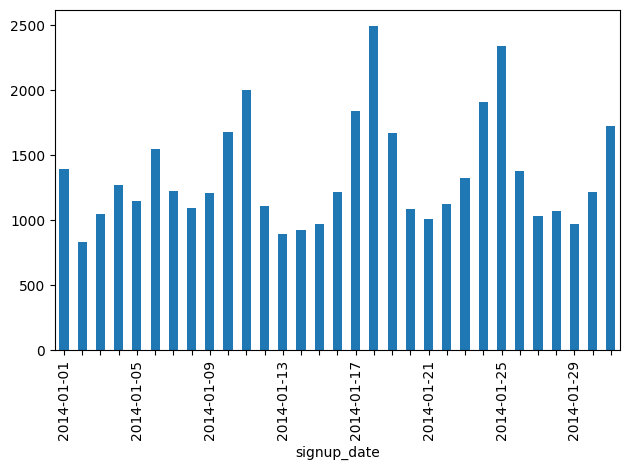

In [31]:
ax = signup_date_counts.plot.bar()
n = 4
for index, label in enumerate(ax.get_xticklabels()):
    if index % n != 0:
        label.set_visible(False)

plt.tight_layout()
plt.show()

As indicated in the project brief, all of the signups for this sample are in the month of January.

In [32]:
last_trip_date_counts = udc['last_trip_date'].value_counts().sort_index()

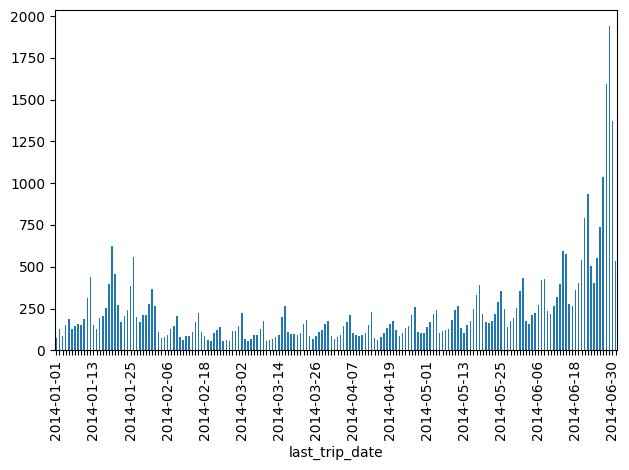

In [33]:
ax = last_trip_date_counts.plot.bar()
n = 12
for index, label in enumerate(ax.get_xticklabels()):
    if index % n != 0:
        label.set_visible(False)

plt.tight_layout()
plt.show()

As we can see, there is a peak of users who stopped using the app during the first month, and then another peak of users who have used the app during the last month. Between these two peaks, there is a valley where the users seem to drop off in an almost linear fashion.

### Heatmap

Let's create a version of the dataframe that can be used in a Heatmap. We won't worry about the cities, but we would like to track time periods. What we are most concerned with is the number of days associated with a given column, rather than its specific date. In other words, we're looking for time intervals; the dates could be anything. 

In [34]:
udc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41744 entries, 0 to 49998
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   city                    41744 non-null  object 
 1   trips_in_first_30_days  41744 non-null  int64  
 2   signup_date             41744 non-null  object 
 3   avg_rating_of_driver    41744 non-null  float64
 4   avg_surge               41744 non-null  float64
 5   last_trip_date          41744 non-null  object 
 6   surge_pct               41744 non-null  float64
 7   ultimate_black_user     41744 non-null  bool   
 8   weekday_pct             41744 non-null  float64
 9   avg_dist                41744 non-null  float64
 10  avg_rating_by_driver    41744 non-null  float64
dtypes: bool(1), float64(6), int64(1), object(3)
memory usage: 3.5+ MB


In [35]:
udc['signup_date_dt'] = pd.to_datetime(udc['signup_date'])

In [36]:
udc['last_trip_dt'] = pd.to_datetime(udc['last_trip_date'])

In [37]:
udc['retention_interval'] = (udc['last_trip_dt'] - udc['signup_date_dt']).dt.days

In [38]:
udc['retention_interval'].head()

0    143
1     96
2      1
3    170
4     47
Name: retention_interval, dtype: int64

In [39]:
udc_corr = udc.drop(columns=['city', 'signup_date', 'last_trip_date', 'signup_date_dt', 'last_trip_dt', 'ultimate_black_user'])

In [40]:
udc_corr = udc_corr.corr()

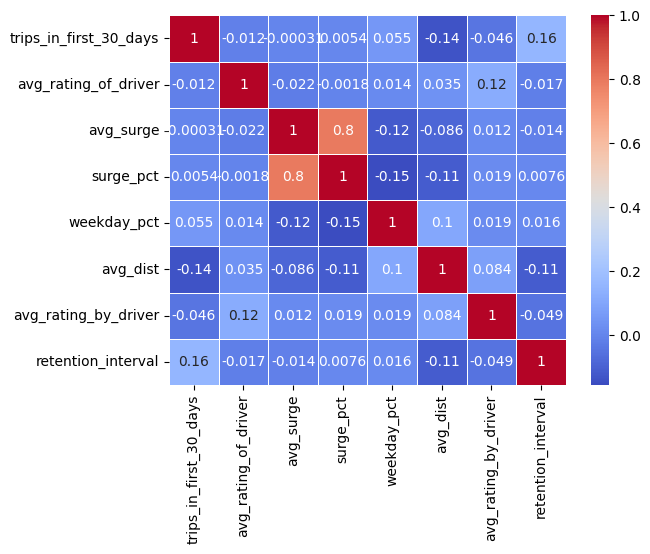

In [41]:
sns.heatmap(udc_corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.show()

This quick correlation matrix suggests that the features that correlate most heavily with `retention_interval` are `avg_dist` and `trips_in_first_30_days`.

This might suggest that users who routinely have a higher need for long trips are more likely to continue with the app.

### Percentage of Users Retained

Let's answer the question regarding the fraction of users that were retained. To answer this question, we'll look at the number of users who have used the app within the past thirty days, which is the month of June.

In [42]:
type(udc['last_trip_date'].iloc[0])

str

In [43]:
last_trip_dt = pd.to_datetime(udc['last_trip_date'])

In [44]:
type(last_trip_dt.head())

pandas.core.series.Series

In [45]:
within_thirty = last_trip_dt[last_trip_dt >= pd.to_datetime('2014-06-01')]

In [46]:
count_within_thirty = len(within_thirty)

In [47]:
count_total = len(udc)

In [48]:
perc_retained = round(count_within_thirty / count_total, 2) * 100

In [49]:
print(f'Users retained: {perc_retained}%')

Users retained: 41.0%


## Predictive Model

Let's build a model to predict user retention. We'll try Linear Regression, OLS, and Ridge Regression.

Again, we don't specifically need the datetime features for this. What we really need is the interval between their signup day and their last trip.

Let's create yet another version of the dataframe and then split the dataset. We'll convert the cities to dummy variables and drop all the datetime objects.

Our target variable is `retention_interval`, where more days is better.

In [50]:
udc_model = udc.drop(columns=['signup_date', 'last_trip_date', 'signup_date_dt', 'last_trip_dt'])

In [51]:
udc_model = pd.get_dummies(udc_model, columns=['city'], prefix='c')

In [52]:
udc_model.head(1)

,trips_in_first_30_days,avg_rating_of_driver,avg_surge,surge_pct,ultimate_black_user,weekday_pct,avg_dist,avg_rating_by_driver,retention_interval,c_Astapor,c_King's Landing,c_Winterfell
0,4,4.7,1.1,15.4,True,46.2,3.67,5.0,143,False,True,False


In [53]:
udc_model.columns = udc_model.columns.astype(str)

### Train Test Split

In [54]:
X = pd.DataFrame(udc_model.drop(columns=['retention_interval']))
y = pd.DataFrame(udc_model['retention_interval'])

In [55]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [56]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(31308, 11)
(10436, 11)
(31308, 1)
(10436, 1)


### Implementing a Scalar

In [57]:
scaler = StandardScaler()

In [58]:
scaler.fit(X_train)

,copy,True
,with_mean,True
,with_std,True


In [59]:
X_train_scaled = scaler.transform(X_train)

In [60]:
X_test_scaled = scaler.transform(X_test)

### Modeling

### Linear Regression

In [61]:
rModel = linear_model.LinearRegression()

In [62]:
#X_train = X_train.rename(str,axis="columns")
#X_test = X_test.rename(str,axis="columns")
y_train = y_train.rename(str,axis="columns")
y_test = y_test.rename(str,axis="columns")

In [63]:
rModel.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [64]:
y_pred = rModel.predict(X_train_scaled)

In [65]:
r2 = r2_score(y_train, y_pred)

In [66]:
print(r2)

0.10209341887410717


At the moment, our model explains `10%` of the retention interval.

That's an absolutely terrible `r2` score.

### Ordinary Least Squares (OLS)

Let's try OLS.

In [67]:
X_ols = pd.DataFrame(udc_model.drop(columns=['retention_interval']).astype(float))

In [68]:
X_ols = sm.add_constant(X_ols)

In [69]:
y_ols = pd.DataFrame(udc_model[['retention_interval']])

In [70]:
X_ols_train, X_ols_test, y_ols_train, y_ols_test = train_test_split(X_ols, y_ols, test_size=0.25, random_state=42)

In [71]:
scaler = StandardScaler()

In [72]:
scaler.fit(X_ols_train)

,copy,True
,with_mean,True
,with_std,True


In [73]:
X_ols_train_scaled = scaler.transform(X_ols_train)

In [74]:
x_ols_test_scaled = scaler.transform(X_ols_test)

In [75]:
rModel_ols = sm.OLS(y_ols_train, X_ols_train_scaled).fit()

In [76]:
rModel_ols.summary()

/home/bluesanta/jupyterlab/.venv/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:     retention_interval   R-squared (uncentered):                   0.029
Model:                            OLS   Adj. R-squared (uncentered):              0.028
Method:                 Least Squares   F-statistic:                              92.25
Date:                Mon, 27 Jul 2026   Prob (F-statistic):                   6.30e-189
Time:                        02:18:51   Log-Likelihood:                     -1.9268e+05
No. Observations:               31308   AIC:                                  3.854e+05
Df Residuals:                   31298   BIC:                                  3.855e+05
Df Model:                          10                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const               0          0        nan        nan           0           0
x1             6.9518      0.658     10.563      0.000       5.662       8.242
x2            -1.1774      0.653     -1.804      0.071      -2.457       0.102
x3            -2.6254      1.089     -2.410      0.016      -4.761      -0.490
x4             2.8332      1.101      2.574      0.010       0.676       4.990
x5            10.1905      0.654     15.593      0.000       8.909      11.471
x6             0.5792      0.656      0.883      0.377      -0.706       1.865
x7            -6.2768      0.660     -9.506      0.000      -7.571      -4.983
x8            -3.2571      0.655     -4.973      0.000      -4.541      -1.973
x9            -5.7001      0.426    -13.387      0.000      -6.535      -4.866
x10            8.4957      0.481     17.657      0.000       7.553       9.439
x11           -1.5963      0.399     -4.000      0.000      -2.378      -0.814
==============================================================================
Omnibus:                    10015.052   Durbin-Watson:                   0.518
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2538.230
Skew:                          -0.465   Prob(JB):                         0.00
Kurtosis:                       1.960   Cond. No.                          inf
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[3] The smallest eigenvalue is      0. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

#### Observations

The Condition No. `infinity` is as high as can be imagined, which indicates that this model is not producing quality results.

The R-squared value is still `0.029`, implying a `03%` efficacy rate. 

Again, this model is not proving useful.

### Ridge Regression

In [77]:
X_rdg = pd.DataFrame(udc_model.drop(columns=['retention_interval']).astype(float))

In [78]:
y_rdg = pd.DataFrame(udc_model[['retention_interval']])

In [79]:
X_rdg_train, X_rdg_test, y_rdg_train, y_rdg_test = train_test_split(X_rdg, y_rdg, test_size=0.25, random_state=42)

In [80]:
scaler = StandardScaler()

In [81]:
scaler.fit(X_rdg_train)

,copy,True
,with_mean,True
,with_std,True


In [82]:
X_rdg_train_scaled = scaler.transform(X_rdg_train)

In [83]:
X_rdg_test_scaled = scaler.transform(X_rdg_test)

In [84]:
#X_rdg_train = X_rdg_train_scaled.rename(str,axis="columns")
#X_rdg_test = X_rdg_test_scaled.rename(str,axis="columns")
y_rdg_train = y_rdg_train.rename(str,axis="columns")
y_rdg_test = y_rdg_test.rename(str,axis="columns")

In [85]:
model_pipeline = make_pipeline(StandardScaler(), Ridge(alpha=1.0))

In [86]:
model_pipeline.fit(X_rdg_train_scaled, y_rdg_train)

,steps,"[('standardscaler', ...), ('ridge', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None


In [87]:
predictions = model_pipeline.predict(X_rdg_test)
print(f"R² Score: {r2_score(y_rdg_test, predictions):.3f}")
print(f"RMSE: {root_mean_squared_error(y_rdg_test, predictions):.3f}")

R² Score: -1.220
RMSE: 91.352


/home/bluesanta/jupyterlab/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


Again, we see an extremely low R2 score, this time implying `-122%` efficiency, and the RMSE has a low value of `91.352`.

### Reducing Features

Let's try Linear Regression, but with only the two features that showed signs of correlation.

In [88]:
udc_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41744 entries, 0 to 49998
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   trips_in_first_30_days  41744 non-null  int64  
 1   avg_rating_of_driver    41744 non-null  float64
 2   avg_surge               41744 non-null  float64
 3   surge_pct               41744 non-null  float64
 4   ultimate_black_user     41744 non-null  bool   
 5   weekday_pct             41744 non-null  float64
 6   avg_dist                41744 non-null  float64
 7   avg_rating_by_driver    41744 non-null  float64
 8   retention_interval      41744 non-null  int64  
 9   c_Astapor               41744 non-null  bool   
 10  c_King's Landing        41744 non-null  bool   
 11  c_Winterfell            41744 non-null  bool   
dtypes: bool(4), float64(6), int64(2)
memory usage: 3.0 MB


In [89]:
# X_lim = udc_model['trips_in_first_30_days']
X_lim = udc_model[['avg_dist', 'trips_in_first_30_days']]
y_lim = udc_model['retention_interval']

In [90]:
X_lim_train, X_lim_test, y_lim_train, y_lim_test = train_test_split(X_lim, y_lim, test_size=0.25, random_state=42)

In [91]:
scaler = StandardScaler()

In [92]:
scaler.fit(X_lim_train)

,copy,True
,with_mean,True
,with_std,True


In [93]:
X_lim_train_scaled = scaler.transform(X_lim_train)

In [94]:
X_lim_test_scaled = scaler.transform(X_lim_test)

In [95]:
#X_train_scaled = X_train_scaled.rename(str,axis="columns")
#X_test_scaled = X_test_scaled.rename(str,axis="columns")
#y_lim_train = y_lim_train.rename(str,axis="columns")
#y_lim_test = y_lim_test.rename(str,axis="columns")

In [96]:
rModel.fit(X_lim_train_scaled, y_lim_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [97]:
y_pred = rModel.predict(X_lim_train_scaled)

In [98]:
r2 = r2_score(y_train, y_pred)

In [99]:
print(r2)

0.03308984299202411


The R2 score of `0.03` shows that dropping everything but the correlated columns has an even less useful result.

### Setting Retention Interval to Bool

Let's see if we get a better result if we set the target to a boolean.

In [100]:
udc_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41744 entries, 0 to 49998
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   trips_in_first_30_days  41744 non-null  int64  
 1   avg_rating_of_driver    41744 non-null  float64
 2   avg_surge               41744 non-null  float64
 3   surge_pct               41744 non-null  float64
 4   ultimate_black_user     41744 non-null  bool   
 5   weekday_pct             41744 non-null  float64
 6   avg_dist                41744 non-null  float64
 7   avg_rating_by_driver    41744 non-null  float64
 8   retention_interval      41744 non-null  int64  
 9   c_Astapor               41744 non-null  bool   
 10  c_King's Landing        41744 non-null  bool   
 11  c_Winterfell            41744 non-null  bool   
dtypes: bool(4), float64(6), int64(2)
memory usage: 3.0 MB


In [101]:
udc_model['retention_interval'].describe()

count    41744.000000
mean        98.049324
std         61.229764
min          0.000000
25%         38.000000
50%        118.000000
75%        152.000000
max        181.000000
Name: retention_interval, dtype: float64

In [102]:
udc_model['retention_interval_bool'] = udc_model['retention_interval'] > (30 * 5)

In [103]:
udc_model['retention_interval_bool'].value_counts()

retention_interval_bool
False    30429
True     11315
Name: count, dtype: int64

In [104]:
pd.DataFrame(udc_model['retention_interval_bool'] == True).sum() / pd.DataFrame(udc_model['retention_interval_bool'] == False).sum()

retention_interval_bool    0.371849
dtype: float64

In [105]:
X = pd.DataFrame(udc_model.drop(columns=['retention_interval', 'retention_interval_bool']))
y = pd.DataFrame(udc_model['retention_interval_bool'])

In [106]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [107]:
scaler = StandardScaler()

In [108]:
scaler.fit(X)

,copy,True
,with_mean,True
,with_std,True


In [109]:
X_train_scaled = scaler.transform(X_train)

In [110]:
X_test_scaled = scaler.transform(X_test)

In [111]:
#X_train_scaled = X_train_scaled.rename(str,axis="columns")
#X_test_scaled = X_test_scaled.rename(str,axis="columns")
#y_lim_train = y_lim_train.rename(str,axis="columns")
#y_lim_test = y_lim_test.rename(str,axis="columns")

In [112]:
rModel.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [113]:
y_pred = rModel.predict(X_train_scaled)

In [114]:
r2 = r2_score(y_train, y_pred)

In [115]:
print(r2)

0.09711079093797947


The R2 score of `0.097` continues to show a less usefull result.

# Summary

While we were not able to create a useful predictive model, we still found several useful insights.

Notably, users who travel long distances and use the app frequently in the first thirty days are more likely to become long-term users.

Therefore, the company should research these users and prioritize them.